# New models + Generalizing methods!

Last notebook was, for lack of a better word, pain.

BUT THIS NOTEBOOK WILL HOPEFULLY BE DIFFERENT:

- We now know the approach to take (for discrete parameters initalize separate grids then run separate mcmc runs for each one then compare)
- We have some code to work with
- Just need to generalize it!

In [2]:
import sys
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import splat
sys.path.append("/Users/epritchard/Research/")
import TAPS
import emcee
import scipy.interpolate
import corner
import copy
import astropy.units as u

# NEW IMPORT FOR DISCRETE VALUE COMBOS
import itertools



Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, http://www.github.com/aburgasser/ucdmcmc/


Currently running in error checking mode


Welcome to the Spex Prism Library Analysis Toolkit (SPLAT)!
You are currently using version 2025.12.26

If you make use of any features of this toolkit for your research, please remember to cite the SPLAT paper:

Burgasser et al. (2017, Astro. Soc. India Conf. Series 14, p. 7); Bibcode: 2017ASInC..14....7B

If you make use of any spectra or models in this toolkit, please remember to cite the

## GLOBALS

In [3]:
N_WALKERS = 24

## Plotting Functions!

In [4]:
def chain_plots(sampler, 
                *,
                N_BURN=1000,
                key,
                **kwargs
                ):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    par_columns = interp_cols_dict[key]
    # if key:
    #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}
    for i in range(chain_N):
        chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

    for key in chain_dict:
        plt.figure(figsize=(8,6))
        plt.plot(chain_dict[key].T) 
        plt.xlabel('Step Number')
        plt.ylabel(f"{key}")
        plt.show()




def plot_steps(sampler,
            *,
            Nburn=1000,
            key,
            ):
    
    
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}

    for i in range(chain_N):
        chain_dict[interp_cols_dict[bestfit_grid_key][i]] = sampler.flatchain[Nburn*sampler.nwalkers:, i]

    

    corner.corner(np.array(list(chain_dict.values())).T, 
                show_titles=True, 
                color="gray", 
                titles=(list(chain_dict.keys())), 
                quantiles=[0.16, .5, .84], 
                )
    

    
def plot_fit(sampler, sp, key,
             *,
             verbose = False):
    
    argmax = np.argmax(sampler.get_log_prob())
    bestfit_param = sampler.flatchain[argmax]
    # print(bestfit_param)

    fleep = interp_dict[key](bestfit_param)

    alpha = np.nansum(((sp.flux.value) * (fleep)) / (sp.noise.value**2)) / np.nansum((fleep**2) / (sp.noise.value**2))

    # print(alpha)
    # print(alpha*fleep[0,:])
    # print(sp.flux.value)
    if verbose:
        chi, scl, dof = ucdmcmc.compareSpec(sp.flux.value, alpha*fleep[0,:], sp.noise.value)
        print(f"{chi/dof}")
    plt.Figure(figsize=(8,8))
    plt.plot(sp.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
    plt.plot(sp.wave.value, sp.flux.value, label=sp.name, c="black")
    plt.legend()
    plt.show()

## EMCEE pipeline functions

### UCDMCMC Function

The plan is to base the fitemcee function on the fitmcmc function--which means some methods like distinguishing between discrete and continuous parameters as well as finding their limits are already made! 

So for now I am going to return the parameter parsing part of the fitMCMC function and use those outputs for my functions!

In [4]:
# Model with NO discrete columns
# =================================
# models, wave = ucdmcmc.getModelSet("dback24")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 1 discrete column (3 discrete values)
# =================================
# models, wave = ucdmcmc.getModelSet("lacy23")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 2 discrete columns (2 discrete values each)
# =================================
models, wave = ucdmcmc.getModelSet("atmo20")
sp = ucdmcmc.getSample("SPEX-PRISM")

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404


In [11]:
def fitMCMC(spc,models,p0={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='all',
	pstep=ucdmcmc.DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,
	quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
	file_prefix='mcmcfit_',verbose=ucdmcmc.ERROR_CHECKING):
#	radius=np.nan,e_radius=np.nan,report=True):
	'''
	Purpose
	-------

	Fit a spectrum to model grid using a simple Metropolis-Hastings Markov Chain Monte Carlo methor. Conducts the fit
	through model grid by interpolating (logarithmic) fluxes, and advances chains based on various chi-square comparison
	statistics. Returns a variety of outputs depending on the output and report keywords.

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	p0 = {} : dict
		Dictionary containing the initial parameters; if not provided or some parameters missing, default parameters are
		used from the DEFINED_SPECTRAL_MODELS parameter

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'all' : str
		Specify what the function should return; options are:
			* 'best': return a dict of the best-fit model parameters
			* 'model': return the best fit model as a Spectrum class object
			* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
			* 'chain': return the chain of parameter values as a pandas Dataframe
			* 'all' (DEFAULT): returns a dict containing all three of the above 

	pstep = DEFAULT_MCMC_STEPS : dict
		Dictionary containing the parameter step scales. New parameers are selected by a normal distribution with the step
		width, up to the parameter limits

	nstep = 100 : int
		Number of MCMC steps to take; ideally this should be 1000-10000+

	iterim = 50 : int
		If > 0 and report = True, this will iteratively save the chains and diagnostic plots on a cadence of iterim steps

	method = 'chidiff' : str
		The method by which the current (i) and previous (i-1) model fit chi2 values are compared; options are:
			* 'chidiff' (DEFAULT): compare difference in chis to overall miniumum chi2: (chi2[i]-chi2[i-1])/min(chi2)
			* 'survival': compute the F-test survival fraction for the ratio of chi2 values: SF(chi2[i]/chi2[i-1],dof,dof)
			 (see scipy.stats.f)
			* 'dofscale': compares the difference in chi2 values to the dof: dof/(0.5*dof+chi2[1]-chi2[-1])
	treshhold = 0.5 : float
		A scaling factor to determine the acceptance rate for new parameters, where the comparison statistic is compared to a
		uniform draw between [0,threshhold] or [threshhold,1] (depending on the statistic)

	burn = 0.25 : float
		The fraction of the initial chain to remove before determining the final parameter distributions. Set to a low fraction
		if you are starting with a good approximation of the model parameters

	quantscale = [0.25,0.5,0.75] : list
		List of three floats indicating the quantile scales to report for the parameter distributions

	nsample = 0 : int
		For the comparison plot, set to 0 to compare to the best fit model, or to a positive integer to compare to nsample models
		drawn from the chain

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	report = True : bool
		Set to True to save both the chains and several diagnostic plots

	file_prefix = 'mcmcfit_' : str
		Prefix to append to output files if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'best': return a dict of the best-fit model parameters
		* 'model': return the best fit model as a Spectrum class object
		* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
		* 'chain': return the chain of parameter values as a pandas Dataframe
		* 'all' (DEFAULT): returns a dict containing all three of the above 

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('sonora21','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=False) # initial fit
	>>> par = ucdmcmc.fitMCMC(spsm,models,p0=par0,nstep=1000,burn=0.25,verbose=False) # MCMC
	>>> par['distributions']
	{'co': array([0.54139703, 0.88476726, 1.25166873]),
	  'kzz': array([2.17372842, 2.90277005, 3.99281996]),
	  'logg': array([4.693938  , 5.10931096, 5.41861495]),
	  'teff': array([ 976.68788945, 1033.00133369, 1090.21418499]),
	  'z': array([-0.35613309, -0.12806126,  0.12211709])}

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			if pd.api.types.is_string_dtype(models[k]) or isinstance(mdls.loc[0,k],str):
				if len(plimits[k])>0:
					par = list(set(list(mdls[k])))
#					print(k,par,plimits[k])
					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
					for p in par:
						if p not in plimits[k]: 
							mdls = mdls[mdls[k]!=p]
							# mdls.reset_index(inplace=True,drop=True) ########
				mdls.reset_index(inplace=True,drop=True)
				
			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	# print(mdls["model"])
	mset = mdls.loc[0,'model']
	mkys = list(mdls.keys())
	for x in ['model','file',flux_name]:
		if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
	chk = True
	for k in mkys: chk=(chk and (k in list(p0.keys())))
	if chk==False:
		if verbose==True: print('Running initial grid fit')
		p0 = fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
		if flux_name in list(p0.keys()): del p0[flux_name]
		if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
	mkysfit = copy.deepcopy(mkys)
	for x in ['file','model','scale','dof','rchi']:
		if x in mkysfit: mkysfit.remove(k)
	for k in mkys:
		vals = list(set(list(mdls[k])))
		vals.sort()
		if len(vals)<2: pstep[k] = 0.
		else:
			if k not in list(pstep.keys()):
				if isinstance(vals[0],str): pstep[k] = -1.
				else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
		if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
	for k in ucdmcmc.ALT_PARAMETERS:
		if k in list(p0.keys()):
			if k not in list(pstep.keys()): pstep[k] = 0
			if pstep[k] > 0: 
				mkysfit.append(k)
	nparam = len(mkysfit)

# set defaults for required model parameters
	for k in mkysfit: 
		if k not in list(p0.keys()):
			if k in list(mdls.columns): p0[k] = ucdmcmc.DEFINED_SPECTRAL_MODELS[mset]['default'][k]
			elif k in list(ucdmcmc.PARAMETERS.keys()): p0[k] = ucdmcmc.PARAMETERS[k]['default']
			else: 
				if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
				mkysfit.remove(k)
				nparam = len(mkysfit)

# set limits for fitting parameters
	for k in mkysfit: 
		if k not in list(plimits.keys()):
			if k in list(mdls.columns): 
				vals = list(set(list(mdls[k])))
				vals.sort()
				if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
				else: plimits[k] = vals
			elif k in list(ucdmcmc.PARAMETERS.keys()): plimits[k] = ucdmcmc.PARAMETERS[k]['limits']
			else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
	pfitc,pfitd = {},{}
	if verbose==True: print('Fitting the following parameters:')
	for k in mkysfit: 
		if k in list(p0.keys()):
			if isinstance(p0[k],str)==True: 
				pfitd[k] = p0[k]
				if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
			else: 
				pfitc[k] = p0[k]
				if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))

	return pfitc, pfitd, plimits 

# FOR NOW DO NOT NEED THE REST 
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================

# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# # some plotting set up
# 	ylabelpre = 'Scaled '
# 	if absolute==True: ylabelpre='Absolute '

# # initialize MCMC
# 	cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
# 	chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 	dof = dof-nparam
# 	cmdl.scale(scl) 
# 	chis = [chi]
# 	pvals = [p0]
# 	mdlflxs = [cmdl.flux.value]
# 	scales = [scl]

# # run MCMC
# 	if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
# 	for i in tqdm(range(nstep)):
# 		pnew = copy.deepcopy(pvals[-1])
# # continuous variables		
# # constrain to be within specified limits
# 		for k in list(pfitc.keys()): 
# 			pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
# 			pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
# 			pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# # discrete variables
# 		for k in list(pfitd.keys()): 
# #			vals = list(set(list(mdls[k])))
# 			pnew[k] = np.random.choice(plimits[k])
# # do we need this next line?			
# #		pnew = pnew | pfitd
# # try grid model			
# 		try:
# 			cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # try interpolated model			
# 		# except:
# 		# 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # model can't be read, stay in place
# 		except: 
# 			if verbose==True: print('Error reading in parameters {}'.format(pnew))
# 			pvals.append(pvals[-1])
# 			chis.append(chis[-1])
# 			scales.append(scales[-1])
# 			mdlflxs.append(mdlflxs[-1])
# # compare model			
# 		else:
# #			if verbose==True: print(i,pnew)
# 			chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 			# if np.isnan(radius)==False and np.isnan(e_radius)==False:
# 			#	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
# 			#if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

# 	# compute statistic
# 			if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
# 			elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
# 			elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
# 			else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
# 	#			if verbose==True: print(chinew,chis[-1],dof,st,chst)

# 			if st<chst:
# 	# reset if we've wandered off
# 				if chinew>(1+2*threshhold)*np.nanmin(chis):
# 					if verbose==True: print('RESETING TO BEST FIT')
# 					pvals.append(pvals[np.argmin(chis)])
# 					chis.append(chis[np.argmin(chis)])
# 					scales.append(scales[np.argmin(chis)])
# 					mdlflxs.append(mdlflxs[np.argmin(chis)])
# 	# criterion satisfied, make a move
# 				else:
# 					if verbose==True: print('CHANGED PARAMETERS!')
# 					pvals.append(pnew)
# 					chis.append(chinew)
# 					scales.append(scl)
# 					mdlflxs.append(cmdl.flux.value)
# 	# criterion not satisfied, stay in place
# 			else:
# 				pvals.append(pvals[-1])
# 				chis.append(chis[-1])
# 				scales.append(scales[-1])
# 				mdlflxs.append(mdlflxs[-1])
# # iterim save
# 		if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# # save parameters
# 			dpfit = pandas.DataFrame()
# 			for k in list(pvals[0].keys()): 
# 				dpfit[k] = [p[k] for p in pvals]
# 			dpfit['chis'] = chis
# 			dpfit['dof'] = [dof]*len(dpfit)
# 			dpfit['scale'] = scales
# 			dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
# 			outfile = file_prefix+'_parameters.xlsx'
# 			dpfit.to_excel(outfile,index=False)
# # plot comparison
# 			if verbose==True: print('Saving iterim plots')
# 			pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# #			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
# 			cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
# 			# print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
# 			# cmdl.scale(scales[np.argmin(chis)])
# 			# print(np.nanmax(cmdl.flux.value))
# 			label = '{} model '.format(mset)
# 			label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
# 			label+='T={:.0f} '.format(pbest['teff'])
# 			label+='logg={:.2f} '.format(pbest['logg'])
# 			label+='z={:.2f} '.format(pbest['z'])
# 			outfile = file_prefix+'_compare.pdf'
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# # plot cornerplot
# 			plotpars = copy.deepcopy(mkysfit)
# 			for k in plotpars:
# 				if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 			if absolute==True: plotpars.append('radius')
# 			pbest = {}
# 			for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 			weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 			outfile = file_prefix+'_corner.pdf'
# 			try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 			except: print('Warning: had trouble making corner plot')
# # plot chains
# 			plotpars.append('chis')
# 			plotpars.append('scale')
# 			outfile = file_prefix+'_chains.pdf'
# 			plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # remove burn in
# 	pvalsb = pvals[int(burn*nstep):]
# 	dpfit = pandas.DataFrame()
# 	for k in list(pvalsb[0].keys()): 
# 		dpfit[k] = [p[k] for p in pvalsb]
# 	dpfit['chis'] = chis[int(burn*nstep):]
# 	dpfit['dof'] = [dof]*len(dpfit)
# 	dpfit['scale'] = scales[int(burn*nstep):]
# 	dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# # best fit parameters
# 	pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# 	pvalsb[np.argmin(chis[int(burn*nstep):])]
# 	for x in [flux_name,'file']:
# 		if x in list(pbest.keys()): del pbest[x]
# 	if verbose==True or report==True: 
# 		print('\nBest parameters:')
# 		for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
# 	cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 	if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# # distribution of values
# 	pdist = {}
# 	dpars = copy.deepcopy(mkysfit)
# 	for k in dpars:
# 		if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
# 	if absolute==True: 
# 		pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

# 	if report == True:
# # remove initial burn and save
# 		outfile = file_prefix+'_parameters.xlsx'
# 		if verbose==True: print('Saving database of prameters to {}'.format(outfile))
# 		dpfit.to_excel(outfile,index=False)
# # plot comparison
# 		# cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 		# if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
# 		label = '{} model '.format(mdls.loc[0,'model'])
# 		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
# 		label+='T={:.0f} '.format(pbest['teff'])
# 		label+='logg={:.2f} '.format(pbest['logg'])
# 		label+='z={:.2f} '.format(pbest['z'])
# 		outfile = file_prefix+'_compare.pdf'
# 		if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
# 		if nsample<=0: 
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# 		else:
# 			plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# # plot cornerplot
# 		plotpars = copy.deepcopy(mkysfit)
# 		for k in plotpars:
# 			if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 		if absolute==True: plotpars.append('radius')
# 		pbest = {}
# 		for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 		weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 		outfile = file_prefix+'_corner.pdf'
# 		if verbose==True: print('Plotting corner plot to {}'.format(outfile))
# 		try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 		except: print('Warning: had trouble making corner plot')
# # plot chains
# 		plotpars.append('chis')
# 		plotpars.append('scale')
# 		outfile = file_prefix+'_chains.pdf'
# 		if verbose==True: print('Plotting chain plot to {}'.format(outfile))
# 		plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # return depending on output keyword
# 	if 'best' in output.lower(): return pbest
# 	elif 'spec' in output.lower(): return cmdl
# 	elif 'dist' in output.lower(): return pdist
# 	elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
# 	else:
# 		return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}


def fitGrid(spc,models,altpar={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='parameters',absolute=False,
	report=True,xscale='linear',yscale='linear',file_prefix='gridfit_',verbose=ucdmcmc.ERROR_CHECKING):
	'''
	Purpose
	-------

	Fit a spectrum to model grid, with optional constraints. This function uses a chi-square statistic and determines the
	overall best fit model from a set of model fluxes. 

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'parameters' : str
		Specify what the program should return; options are:
			* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
			* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
			* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
				and degrees of freedom added

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	report = True : bool
		Set to True to save an output file showing the best fit model

	file_prefix = 'gridfit_' : str
		Prefix to append to output file if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
		* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
		* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
			and degrees of freedom added

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=True)

	Best fit model:
		model = elfowl24
		co = 0.5
		kzz = 2.0
		logg = 5.0
		teff = 1000.0
		z = -0.0
		scale = 1.387711853929069e-24
		chi = 956.6257633740316
		radius = 0.0005224902503080241
		dof = 850.0
		rchi = 1.1254420745576843
		reduced chi2 = 1.1254420745576843

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			if pd.api.types.is_string_dtype(models[k]) or isinstance(mdls.loc[0,k],str):
				par = list(set(list(mdls[k]))) # Changed dp --> mdls to properly mask for specific discrete parameters
				if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
				for p in par:
					if p not in plimits[k]: mdls = mdls[mdls[k]!=p]
				mdls.reset_index(inplace=True,drop=True)

			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	
# run through each grid point
	for x in ['scale','chis','radius','dof']: mdls[x] = [np.nan]*len(mdls)
	for jjj in range(len(mdls)):
		if len(altpar)>0:
			mdln = ucdmcmc.Spectrum(wave=spscl.wave,flux=np.array(mdls.loc[jjj,flux_name])*spscl.flux.unit)
			mdln.applyPar(altpar)
			mdlind = mdln.flux.value
		else: mdlind = np.array(mdls.loc[jjj,flux_name])
		chi,scl,dof = ucdmcmc.compareSpec(spscl.flux.value,mdlind,spscl.noise.value,verbose=verbose)
		mdls.loc[jjj,'chis'] = chi
		mdls.loc[jjj,'scale'] = scl
		mdls.loc[jjj,'dof'] = dof
# radius scaling assuming spectrum is in absolute flux units
		mdls.loc[jjj,'radius'] = (10.*u.pc*(scl**0.5)).to(u.Rsun).value
#	mdls['model'] = [mset]*len(mdls)

# best fit
	mpar = dict(mdls.loc[np.argmin(mdls['chis']),:])
	mpar['rchi'] = mpar['chis']/mpar['dof']
	dpars = list(mdls.keys())
	for x in [flux_name,'file']:
		if x in list(mpar.keys()): del mpar[x]
	if verbose==True or report==True: 
		print('\nBest parameters:')
		for k in mpar: print('\t{} = {}'.format(k,mpar[k]))
	comp = ucdmcmc.getGridModel(mdls,mpar,spscl.wave,verbose=verbose)
	if len(altpar)>0: 
		comp.applyPar(altpar)
		mpar = mpar | altpar
#	comp.scale(mpar['scale'])
#	comp = splat.Spectrum(wave=wave,flux=np.array(mdls.loc[ibest,flux_name])*mdls.loc[ibest,'scale']*spscl.flux.unit)
	diff = spscl.flux.value-comp.flux.value
#	dof = np.count_nonzero(~np.isnan(spscl.flux.value))-1
	# sclstd = np.nanstd(diff.flux.value,ddof=1)/np.nanmax(spscl.flux.value)
	# mpar['sclstd'] = sclstd

	if report == True:
# save parameters
		outfile = file_prefix+'_parameters.xlsx'
		mdls.drop(columns=[flux_name],inplace=True)
		mdls.to_excel(outfile,index=False)
# comparison plot		
		outfile = file_prefix+'_compare.pdf'
		label = '{} model '.format(mdls.loc[0,'model'])
		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(mpar['rchi'])
		label+='T={:.0f} '.format(mpar['teff'])
		label+='logg={:.2f} '.format(mpar['logg'])
		label+='z={:.2f} '.format(mpar['z'])
		ucdmcmc.plotCompare(spscl,comp,outfile=outfile,clabel=label,absolute=absolute,xscale=xscale,yscale=yscale)
	return mpar

models, wave = ucdmcmc.getModelSet("sand24")
sp = ucdmcmc.getSample("SPEX-PRISM")

pfitc, pfitd, plimits = fitMCMC(sp, models)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
Running initial grid fit

Grid fit parameters: {'model': 'sand24', 'enrich': -0.05, 'logg': 6.0, 'teff': 1200.0, 'z': -0.15, 'scale': 8.030159259522041e-20, 'chis': 191596.6551523993, 'radius': 0.12568707550436364, 'dof': 562.0, 'rchi': 340.91931521779236}
Fitting the following parameters:
	enrich: initial=-0.05 step=0.05 min=-0.05 max=0.4
	logg: initial=6.0 step=0.1 min=2.0 max=6.0
	teff: initial=1200.0 step=25 min=700.0 max=4000.0
	z: initial=-0.15 step=0.1 min=-2.4 max=0.3


my attempt at general grid creation method:

In [12]:
def get_emcee_grids():

    # Assuming pfitc, pfitd, plimits, models, wave are all created

    interp_dict = {}
    interp_keys = []
    interp_mask_dict = {}

    # For modelsets with NO discrete parameters 
    if len(pfitd) == 0:

        # NEED TO PUT A TRY STATEMENT
        interp_keys.append("0")

        # For consistency of return statement
        std_mask = models[pfitc.keys()].std(axis=0) != 0
        interp_mask_dict["0"] = std_mask

        # Interpolation Time!
        interp_dict["0"] = scipy.interpolate.LinearNDInterpolator(models[list(pfitc.keys())].to_numpy()[:, std_mask], np.stack(models["flux"].to_numpy()), rescale=True)
    

    # For modelsets with 1 discrete parameter
    elif len(pfitd) == 1:
        # NEED TO PUT A TRY STATEMENT
        print("PROCCED pfit = 1")
        for value in plimits[list(pfitd.keys())[0]]:

            # Need this mask to grab rows with the correct discrete parameter 
            discrete_value_mask = models[list(pfitd.keys())[0]] == value

            # Need this mask to only grab columns of continuous parameters which are actually varying
            std_mask = models[discrete_value_mask][list(pfitc.keys())].std(axis=0) != 0

            # Updating our lists and dictionaries!
            interp_keys.append(value)
            interp_mask_dict[value] = std_mask

            # Actual output (it looks gross I know I know)
            interp_dict[value] = scipy.interpolate.LinearNDInterpolator(models[discrete_value_mask][list(pfitc.keys())].to_numpy()[:, std_mask], np.stack(models[discrete_value_mask]["flux"].to_numpy()), rescale=True)
        

    # For modelsets with more than 1 discrete parameter!
    elif len(pfitd) > 1:
        print("PROCCED pfit > 1")
        # Okay this part is a bit open ended--in the previously notebook I assigned the discrete values to numbers (either 0 or 1 for a specific column)
        # But I can just have the keys for the dictionary be the actual values for each column
        # But for now it is just the number mapping.


        discrete_mapper = {}
        discrete_list = []
        # discrete_list_mapped = []


        for key in pfitd:
            # mapped = []

            for i in range(len(plimits[key])):
                discrete_mapper[plimits[key][i]] = i
                # mapped.append(i)

            discrete_list.append(plimits[key])
            # discrete_list_mapped.append(mapped)

        discrete_combo_list = list(itertools.product(*discrete_list))
        # discrete_combo_mapped = list(itertools.product(*discrete_list_mapped))

        for combo in discrete_combo_list:

            discrete_value_masks = []

            for i, key in enumerate(pfitd):
                # discrete_value_masks = []
                discrete_value_masks.append(models[key] == combo[i])

            master_mask = np.logical_and.reduce(discrete_value_masks)
            std_mask = models[master_mask][list(pfitc.keys())].std(axis=0) != 0

            interp_keys.append(combo)
            interp_mask_dict[combo] = std_mask
            
            try:
                interp_dict[combo] = scipy.interpolate.LinearNDInterpolator(models[master_mask][list(pfitc.keys())].to_numpy()[:, std_mask], np.stack(models[master_mask]["flux"].to_numpy()), rescale=True)
            
            except ValueError:
                interp_dict[combo] = np.nan
                print(f"{combo} DOES NOT EXIST")
        



        

    else:
        raise ValueError(f"erm wtf is happening to pfitd... its {pfitd}")
        
        

    
    return interp_dict, interp_keys, interp_mask_dict

glorp_dict, glorp_keys, glorp_mask_dict = get_emcee_grids()

claude optimizing my code :(

In [13]:
def get_emcee_grids_cl():

    interp_dict = {}
    interp_cols_dict = {}
    interp_mask_dict = {}
    
    discrete_keys = list(pfitd.keys())
    combos = list(itertools.product(*(plimits[k] for k in discrete_keys))) or [()] # grrrrrr I didnt even know you can do that >:(

    for combo in combos:
        if combo:
            mask = np.logical_and.reduce([models[k] == v for k, v in zip(discrete_keys, combo)]) # I forgot zip existed O-O thats actually kinda smart
            sub = models[mask]
        else:
            sub = models
        cols = list(pfitc.keys())
        pts = sub[cols].to_numpy()
        std_mask = sub[cols].std(axis=0).to_numpy() != 0
        active_cols = [c for c, keep in zip(cols, std_mask) if keep]
        try:
            interp_dict[combo] = scipy.interpolate.LinearNDInterpolator(
                                                                    pts[:, std_mask], 
                                                                    np.stack(sub["flux"].to_numpy()), 
                                                                    rescale=True)
            
        except ValueError:
            interp_dict[combo] = np.nan
            print(f"{combo} DOES NOT EXIST")
            
        interp_mask_dict[combo] = sub
        interp_cols_dict[combo] = active_cols          # keep the labels too

    
    return interp_dict, interp_cols_dict, interp_mask_dict

In [14]:
interp_dict, interp_cols_dict, interp_mask_dict = get_emcee_grids_cl()


Best parameters:
	model = sand24
	enrich = -0.05
	logg = 6.0
	teff = 1200.0
	z = -0.15
	scale = 8.030159259522041e-20
	chis = 191596.6551523993
	radius = 0.12568707550436364
	dof = 562.0
	rchi = 340.91931521779236


<Figure size 640x480 with 0 Axes>

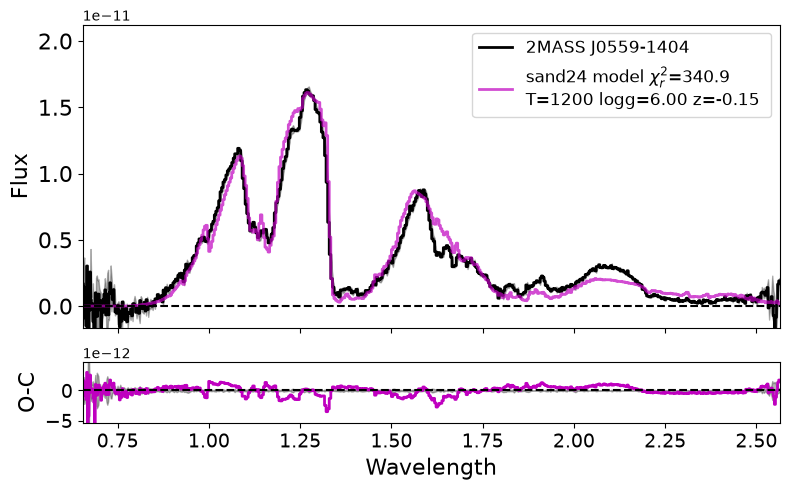

{'model': 'sand24',
 'enrich': -0.05,
 'logg': 6.0,
 'teff': 1200.0,
 'z': -0.15,
 'scale': 8.030159259522041e-20,
 'chis': 191596.6551523993,
 'radius': 0.12568707550436364,
 'dof': 562.0,
 'rchi': 340.91931521779236}

In [15]:
fitGrid(sp, models)

In [17]:
def get_ipar(
        key,
        *,
        par=False
        ):
    # Assuming the following variables exist:
    # - models & wave (from ucdmcmc.getModelSet())
    # - pfitc, pfitd, plimits (from ucdmcmc.fitmcmc)
    # - interp_dict, interp_cols_dict, interp_mask_dict (from get_emcee_grids())

    # key should be the discrete parameters for interp_dict & interp_cols_dict & interp_mask_dict

    p_limits = {}
    p_lower = []
    p_upper = []
    p_random = []

    for column in interp_cols_dict[key]:
        if par:
            p_random.append(np.random.normal(par[column], 0.01, N_WALKERS))

        else:
            p_limits[column] = [interp_mask_dict[key][column].min(), interp_mask_dict[key][column].max()]
            p_lower.append(p_limits[column][0])
            p_upper.append(p_limits[column][1])
            p_random.append(np.random.uniform(p_limits[column][0], p_limits[column][1], N_WALKERS))


    ipar = np.array(p_random).T
    print(ipar)
    for i in range(N_WALKERS):
        viable = False

        while viable == False:

            if np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
                viable = True

            elif not np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
                if par:
                    # pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]]
                    ipar[i, :] = np.random.normal(pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]].to_numpy()[0,:], 0.01)

                else:
                    ipar[i, :] = np.random.uniform(p_lower, p_upper)

            else:
                print("NOT WORKING AS INTENDED")
                break 

    return ipar

In [18]:
ipar = get_ipar(bestfit_grid_key, par=bestfit_grid)

NameError: name 'bestfit_grid_key' is not defined

In [162]:
interp_cols_dict[bestfit_grid_key]

['logg', 'teff']

In [165]:
bestfit_grid

{'model': 'atmos',
 'ad': 1.0,
 'broad': 'A',
 'cld': 'RO',
 'kzz': 0.0,
 'logg': 4.5,
 'logpmax': 4.0,
 'logpmin': -8.0,
 'teff': 1300.0,
 'z': -0.0,
 'scale': 5.497293276108107e-20,
 'chis': 39875.34636661155,
 'radius': 0.1039927338076278,
 'dof': 562.0,
 'rchi': 70.95257360607037}

In [171]:
florp = pd.DataFrame([bestfit_grid])
florp

,model,ad,broad,cld,kzz,logg,logpmax,logpmin,teff,z,scale,chis,radius,dof,rchi
0,atmos,1.0,A,RO,0.0,4.5,4.0,-8.0,1300.0,-0.0,5.497293e-20,39875.346367,0.103993,562.0,70.952574


In [182]:
pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]].to_numpy()[0,:]


array([   4.5, 1300. ])

In [176]:
florp[interp_cols_dict[bestfit_grid_key]]

,logg,teff
0,4.5,1300.0


In [19]:
def log_L(theta, sp, key):

    x = sp.wave.value
    y = sp.flux.value
    dy = sp.noise.value

    interpolator = interp_dict[key]

    try:
        model = interpolator(theta)

    except:
        print("exit 1")
        return -np.inf

    if not np.all(np.isfinite(model)):
        print(f"exit 2")
        return -np.inf
    
    alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)

    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)
    

Constraining broad to within B
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = B
	cld = LC
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.326999977590408e-20
	chis = 204954.67067697423
	radius = 0.10236933671169804
	dof = 562.0
	rchi = 364.6880261156125


<Figure size 640x480 with 0 Axes>

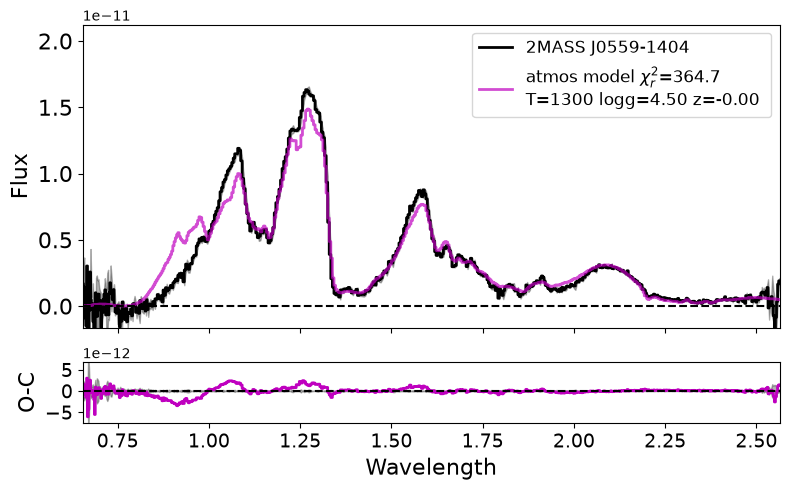

In [141]:
gridfit_dict = fitGrid(sp, models, plimits={"broad":"B", "cld":"LC"})

In [142]:
len(interp_cols_dict[("A", "RO")])

2

In [196]:
models

,model,cld,kzz,logg,teff,z,flux
0,lacy23,AEE10,-0.0,5.00,250.0,-0.5,"[72.01289213513512, 79.38399097189982, 86.3940..."
1,lacy23,AEE10,6.0,4.75,300.0,-0.0,"[85.132071046332, 94.11673369716691, 104.06470..."
2,lacy23,NC,6.0,4.25,600.0,-0.5,"[354.35227196911177, 394.6017960984678, 442.41..."
3,lacy23,NC,-0.0,3.75,500.0,-0.0,"[287.76051331178894, 320.2461772505244, 356.87..."
4,lacy23,AEE10,6.0,5.00,350.0,-0.5,"[125.3194099459459, 137.78130213655385, 151.44..."
...,...,...,...,...,...,...,...
1440,lacy23,E10,6.0,4.75,250.0,-0.5,"[51.33428793436293, 56.54334528564806, 61.4308..."
1441,lacy23,NC,-0.0,4.75,225.0,-0.5,"[47.63674286703609, 52.7726179809259, 56.84913..."
1442,lacy23,NC,-0.0,3.50,225.0,0.5,"[8.675657476108006, 10.854184012386595, 13.107..."
1443,lacy23,NC,-0.0,5.00,425.0,0.5,"[756.0514275546336, 834.3701249127726, 919.954..."


In [211]:
models

,model,cld,co,logg,teff,z,flux
0,exorem21,SIMPLE,0.10,4.0,1000.0,-0.49,"[9736.602601232886, 11755.20590069062, 14077.6..."
1,exorem21,NC,0.10,4.0,1000.0,-0.49,"[2409.2983149829734, 2954.249804065428, 3621.1..."
2,exorem21,SIMPLE,0.15,4.0,1000.0,-0.49,"[25934.577763960297, 30720.947169107425, 36046..."
3,exorem21,NC,0.15,4.0,1000.0,-0.49,"[3818.568585351585, 4769.63458990129, 5928.891..."
4,exorem21,SIMPLE,0.20,4.0,1000.0,-0.49,"[12374.801450387842, 15016.713607670894, 18062..."
...,...,...,...,...,...,...,...
13379,exorem21,SIMPLE,0.60,4.5,950.0,-0.00,"[6386.1702346361035, 7196.320516570679, 8082.9..."
13380,exorem21,SIMPLE,0.20,5.0,950.0,-0.49,"[5695.9885683754965, 7135.498365811535, 8905.3..."
13381,exorem21,SIMPLE,0.55,5.0,950.0,-0.49,"[7582.645037318916, 9178.512565711879, 11049.7..."
13382,exorem21,SIMPLE,0.20,5.0,950.0,-0.00,"[2084.6892873944776, 2398.6446023262333, 2748...."


## START HERE!!!!

In [5]:
N_WALKERS = 24

def chain_plots(sampler, 
                *,
                N_BURN=1000,
                key,
                **kwargs
                ):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    par_columns = interp_cols_dict[key]
    # if key:
    #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}
    for i in range(chain_N):
        chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

    for key in chain_dict:
        plt.figure(figsize=(8,6))
        plt.plot(chain_dict[key].T) 
        plt.xlabel('Step Number')
        plt.ylabel(f"{key}")
        plt.show()




def plot_steps(sampler,
            *,
            Nburn=1000,
            key,
            ):
    
    
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}

    for i in range(chain_N):
        chain_dict[interp_cols_dict[bestfit_grid_key][i]] = sampler.flatchain[Nburn*sampler.nwalkers:, i]

    

    corner.corner(np.array(list(chain_dict.values())).T, 
                show_titles=True, 
                color="gray", 
                titles=(list(chain_dict.keys())), 
                quantiles=[0.16, .5, .84], 
                )
    

    
def plot_fit(sampler, sp, key,
             *,
             verbose = False):
    
    argmax = np.argmax(sampler.get_log_prob())
    bestfit_param = sampler.flatchain[argmax]
    # print(bestfit_param)

    fleep = interp_dict[key](bestfit_param)

    alpha = np.nansum(((sp.flux.value) * (fleep)) / (sp.noise.value**2)) / np.nansum((fleep**2) / (sp.noise.value**2))

    # print(alpha)
    # print(alpha*fleep[0,:])
    # print(sp.flux.value)
    if verbose:
        chi, scl, dof = ucdmcmc.compareSpec(sp.flux.value, alpha*fleep[0,:], sp.noise.value)
        print(f"{chi/dof}")
    plt.Figure(figsize=(8,8))
    plt.plot(sp.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
    plt.plot(sp.wave.value, sp.flux.value, label=sp.name, c="black")
    plt.legend()
    plt.show()

In [6]:
def fitMCMC(spc,models,p0={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='all',
	pstep=ucdmcmc.DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,
	quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
	file_prefix='mcmcfit_',verbose=ucdmcmc.ERROR_CHECKING):
#	radius=np.nan,e_radius=np.nan,report=True):
	'''
	Purpose
	-------

	Fit a spectrum to model grid using a simple Metropolis-Hastings Markov Chain Monte Carlo methor. Conducts the fit
	through model grid by interpolating (logarithmic) fluxes, and advances chains based on various chi-square comparison
	statistics. Returns a variety of outputs depending on the output and report keywords.

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	p0 = {} : dict
		Dictionary containing the initial parameters; if not provided or some parameters missing, default parameters are
		used from the DEFINED_SPECTRAL_MODELS parameter

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'all' : str
		Specify what the function should return; options are:
			* 'best': return a dict of the best-fit model parameters
			* 'model': return the best fit model as a Spectrum class object
			* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
			* 'chain': return the chain of parameter values as a pandas Dataframe
			* 'all' (DEFAULT): returns a dict containing all three of the above 

	pstep = DEFAULT_MCMC_STEPS : dict
		Dictionary containing the parameter step scales. New parameers are selected by a normal distribution with the step
		width, up to the parameter limits

	nstep = 100 : int
		Number of MCMC steps to take; ideally this should be 1000-10000+

	iterim = 50 : int
		If > 0 and report = True, this will iteratively save the chains and diagnostic plots on a cadence of iterim steps

	method = 'chidiff' : str
		The method by which the current (i) and previous (i-1) model fit chi2 values are compared; options are:
			* 'chidiff' (DEFAULT): compare difference in chis to overall miniumum chi2: (chi2[i]-chi2[i-1])/min(chi2)
			* 'survival': compute the F-test survival fraction for the ratio of chi2 values: SF(chi2[i]/chi2[i-1],dof,dof)
			 (see scipy.stats.f)
			* 'dofscale': compares the difference in chi2 values to the dof: dof/(0.5*dof+chi2[1]-chi2[-1])
	treshhold = 0.5 : float
		A scaling factor to determine the acceptance rate for new parameters, where the comparison statistic is compared to a
		uniform draw between [0,threshhold] or [threshhold,1] (depending on the statistic)

	burn = 0.25 : float
		The fraction of the initial chain to remove before determining the final parameter distributions. Set to a low fraction
		if you are starting with a good approximation of the model parameters

	quantscale = [0.25,0.5,0.75] : list
		List of three floats indicating the quantile scales to report for the parameter distributions

	nsample = 0 : int
		For the comparison plot, set to 0 to compare to the best fit model, or to a positive integer to compare to nsample models
		drawn from the chain

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	report = True : bool
		Set to True to save both the chains and several diagnostic plots

	file_prefix = 'mcmcfit_' : str
		Prefix to append to output files if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'best': return a dict of the best-fit model parameters
		* 'model': return the best fit model as a Spectrum class object
		* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
		* 'chain': return the chain of parameter values as a pandas Dataframe
		* 'all' (DEFAULT): returns a dict containing all three of the above 

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('sonora21','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=False) # initial fit
	>>> par = ucdmcmc.fitMCMC(spsm,models,p0=par0,nstep=1000,burn=0.25,verbose=False) # MCMC
	>>> par['distributions']
	{'co': array([0.54139703, 0.88476726, 1.25166873]),
	  'kzz': array([2.17372842, 2.90277005, 3.99281996]),
	  'logg': array([4.693938  , 5.10931096, 5.41861495]),
	  'teff': array([ 976.68788945, 1033.00133369, 1090.21418499]),
	  'z': array([-0.35613309, -0.12806126,  0.12211709])}

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			# print(k, mdls[k])	
			try:
				if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
					if len(plimits[k])>0:
						par = list(set(list(mdls[k])))
	#					print(k,par,plimits[k])
						if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
						for p in par:
							if p not in plimits[k]: 
								mdls = mdls[mdls[k]!=p]
								# mdls.reset_index(inplace=True,drop=True) ########
					mdls.reset_index(inplace=True,drop=True)
					
				else:
					if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
					mdls = mdls[mdls[k]>=plimits[k][0]]
					mdls = mdls[mdls[k]<=plimits[k][1]]
					mdls.reset_index(inplace=True,drop=True)

			except ValueError:
				print(f"THE {k} COLUMN IS A PROBLEM CHILD--ITS PROCCING AN ERROR")
				continue

			# old code:
			# =================================================================================
# 			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
# 				if len(plimits[k])>0:
# 					par = list(set(list(mdls[k])))
# #					print(k,par,plimits[k])
# 					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
# 					for p in par:
# 						if p not in plimits[k]: 
# 							mdls = mdls[mdls[k]!=p]
# 							# mdls.reset_index(inplace=True,drop=True) ########
# 				mdls.reset_index(inplace=True,drop=True)
				
# 			else:
# 				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
# 				mdls = mdls[mdls[k]>=plimits[k][0]]
# 				mdls = mdls[mdls[k]<=plimits[k][1]]
# 				mdls.reset_index(inplace=True,drop=True)
			# ============================================================================================================
	# print(mdls["model"])
	try: 
		mset = mdls.loc[0,'model']
	except:
		mset = mdls['model']
	mkys = list(mdls.keys())
	for x in ['model','file',flux_name]:
		if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
	chk = True
	for k in mkys: chk=(chk and (k in list(p0.keys())))
	if chk==False:
		if verbose==True: print('Running initial grid fit')
		p0 = fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
		if flux_name in list(p0.keys()): del p0[flux_name]
		if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
	mkysfit = copy.deepcopy(mkys)
	for x in ['file','model','scale','dof','rchi']:
		if x in mkysfit: mkysfit.remove(k)
	for k in mkys:
		vals = list(set(list(mdls[k])))
		vals.sort()
		if len(vals)<2: pstep[k] = 0.
		else:
			if k not in list(pstep.keys()):
				if isinstance(vals[0],str): pstep[k] = -1.
				else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
		if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
	for k in ucdmcmc.ALT_PARAMETERS:
		if k in list(p0.keys()):
			if k not in list(pstep.keys()): pstep[k] = 0
			if pstep[k] > 0: 
				mkysfit.append(k)
	nparam = len(mkysfit)

# set defaults for required model parameters
	for k in mkysfit: 
		if k not in list(p0.keys()):
			if k in list(mdls.columns): p0[k] = ucdmcmc.DEFINED_SPECTRAL_MODELS[mset]['default'][k]
			elif k in list(ucdmcmc.PARAMETERS.keys()): p0[k] = ucdmcmc.PARAMETERS[k]['default']
			else: 
				if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
				mkysfit.remove(k)
				nparam = len(mkysfit)

# set limits for fitting parameters
	for k in mkysfit: 
		if k not in list(plimits.keys()):
			if k in list(mdls.columns): 
				vals = list(set(list(mdls[k])))
				vals.sort()
				if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
				else: plimits[k] = vals
			elif k in list(ucdmcmc.PARAMETERS.keys()): plimits[k] = ucdmcmc.PARAMETERS[k]['limits']
			else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
	pfitc,pfitd = {},{}
	if verbose==True: print('Fitting the following parameters:')
	for k in mkysfit: 
		if k in list(p0.keys()):
			if isinstance(p0[k],str)==True: 
				pfitd[k] = p0[k]
				if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
			else: 
				pfitc[k] = p0[k]
				if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))

	return pfitc, pfitd, plimits 

# FOR NOW DO NOT NEED THE REST 
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================

# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# # some plotting set up
# 	ylabelpre = 'Scaled '
# 	if absolute==True: ylabelpre='Absolute '

# # initialize MCMC
# 	cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
# 	chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 	dof = dof-nparam
# 	cmdl.scale(scl) 
# 	chis = [chi]
# 	pvals = [p0]
# 	mdlflxs = [cmdl.flux.value]
# 	scales = [scl]

# # run MCMC
# 	if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
# 	for i in tqdm(range(nstep)):
# 		pnew = copy.deepcopy(pvals[-1])
# # continuous variables		
# # constrain to be within specified limits
# 		for k in list(pfitc.keys()): 
# 			pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
# 			pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
# 			pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# # discrete variables
# 		for k in list(pfitd.keys()): 
# #			vals = list(set(list(mdls[k])))
# 			pnew[k] = np.random.choice(plimits[k])
# # do we need this next line?			
# #		pnew = pnew | pfitd
# # try grid model			
# 		try:
# 			cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # try interpolated model			
# 		# except:
# 		# 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # model can't be read, stay in place
# 		except: 
# 			if verbose==True: print('Error reading in parameters {}'.format(pnew))
# 			pvals.append(pvals[-1])
# 			chis.append(chis[-1])
# 			scales.append(scales[-1])
# 			mdlflxs.append(mdlflxs[-1])
# # compare model			
# 		else:
# #			if verbose==True: print(i,pnew)
# 			chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 			# if np.isnan(radius)==False and np.isnan(e_radius)==False:
# 			#	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
# 			#if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

# 	# compute statistic
# 			if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
# 			elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
# 			elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
# 			else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
# 	#			if verbose==True: print(chinew,chis[-1],dof,st,chst)

# 			if st<chst:
# 	# reset if we've wandered off
# 				if chinew>(1+2*threshhold)*np.nanmin(chis):
# 					if verbose==True: print('RESETING TO BEST FIT')
# 					pvals.append(pvals[np.argmin(chis)])
# 					chis.append(chis[np.argmin(chis)])
# 					scales.append(scales[np.argmin(chis)])
# 					mdlflxs.append(mdlflxs[np.argmin(chis)])
# 	# criterion satisfied, make a move
# 				else:
# 					if verbose==True: print('CHANGED PARAMETERS!')
# 					pvals.append(pnew)
# 					chis.append(chinew)
# 					scales.append(scl)
# 					mdlflxs.append(cmdl.flux.value)
# 	# criterion not satisfied, stay in place
# 			else:
# 				pvals.append(pvals[-1])
# 				chis.append(chis[-1])
# 				scales.append(scales[-1])
# 				mdlflxs.append(mdlflxs[-1])
# # iterim save
# 		if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# # save parameters
# 			dpfit = pandas.DataFrame()
# 			for k in list(pvals[0].keys()): 
# 				dpfit[k] = [p[k] for p in pvals]
# 			dpfit['chis'] = chis
# 			dpfit['dof'] = [dof]*len(dpfit)
# 			dpfit['scale'] = scales
# 			dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
# 			outfile = file_prefix+'_parameters.xlsx'
# 			dpfit.to_excel(outfile,index=False)
# # plot comparison
# 			if verbose==True: print('Saving iterim plots')
# 			pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# #			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
# 			cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
# 			# print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
# 			# cmdl.scale(scales[np.argmin(chis)])
# 			# print(np.nanmax(cmdl.flux.value))
# 			label = '{} model '.format(mset)
# 			label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
# 			label+='T={:.0f} '.format(pbest['teff'])
# 			label+='logg={:.2f} '.format(pbest['logg'])
# 			label+='z={:.2f} '.format(pbest['z'])
# 			outfile = file_prefix+'_compare.pdf'
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# # plot cornerplot
# 			plotpars = copy.deepcopy(mkysfit)
# 			for k in plotpars:
# 				if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 			if absolute==True: plotpars.append('radius')
# 			pbest = {}
# 			for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 			weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 			outfile = file_prefix+'_corner.pdf'
# 			try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 			except: print('Warning: had trouble making corner plot')
# # plot chains
# 			plotpars.append('chis')
# 			plotpars.append('scale')
# 			outfile = file_prefix+'_chains.pdf'
# 			plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # remove burn in
# 	pvalsb = pvals[int(burn*nstep):]
# 	dpfit = pandas.DataFrame()
# 	for k in list(pvalsb[0].keys()): 
# 		dpfit[k] = [p[k] for p in pvalsb]
# 	dpfit['chis'] = chis[int(burn*nstep):]
# 	dpfit['dof'] = [dof]*len(dpfit)
# 	dpfit['scale'] = scales[int(burn*nstep):]
# 	dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# # best fit parameters
# 	pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# 	pvalsb[np.argmin(chis[int(burn*nstep):])]
# 	for x in [flux_name,'file']:
# 		if x in list(pbest.keys()): del pbest[x]
# 	if verbose==True or report==True: 
# 		print('\nBest parameters:')
# 		for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
# 	cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 	if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# # distribution of values
# 	pdist = {}
# 	dpars = copy.deepcopy(mkysfit)
# 	for k in dpars:
# 		if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
# 	if absolute==True: 
# 		pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

# 	if report == True:
# # remove initial burn and save
# 		outfile = file_prefix+'_parameters.xlsx'
# 		if verbose==True: print('Saving database of prameters to {}'.format(outfile))
# 		dpfit.to_excel(outfile,index=False)
# # plot comparison
# 		# cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 		# if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
# 		label = '{} model '.format(mdls.loc[0,'model'])
# 		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
# 		label+='T={:.0f} '.format(pbest['teff'])
# 		label+='logg={:.2f} '.format(pbest['logg'])
# 		label+='z={:.2f} '.format(pbest['z'])
# 		outfile = file_prefix+'_compare.pdf'
# 		if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
# 		if nsample<=0: 
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# 		else:
# 			plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# # plot cornerplot
# 		plotpars = copy.deepcopy(mkysfit)
# 		for k in plotpars:
# 			if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 		if absolute==True: plotpars.append('radius')
# 		pbest = {}
# 		for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 		weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 		outfile = file_prefix+'_corner.pdf'
# 		if verbose==True: print('Plotting corner plot to {}'.format(outfile))
# 		try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 		except: print('Warning: had trouble making corner plot')
# # plot chains
# 		plotpars.append('chis')
# 		plotpars.append('scale')
# 		outfile = file_prefix+'_chains.pdf'
# 		if verbose==True: print('Plotting chain plot to {}'.format(outfile))
# 		plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # return depending on output keyword
# 	if 'best' in output.lower(): return pbest
# 	elif 'spec' in output.lower(): return cmdl
# 	elif 'dist' in output.lower(): return pdist
# 	elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
# 	else:
# 		return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}


def fitGrid(spc,models,altpar={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='parameters',absolute=False,
	report=True,xscale='linear',yscale='linear',file_prefix='gridfit_',verbose=ucdmcmc.ERROR_CHECKING):
	'''
	Purpose
	-------

	Fit a spectrum to model grid, with optional constraints. This function uses a chi-square statistic and determines the
	overall best fit model from a set of model fluxes. 

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'parameters' : str
		Specify what the program should return; options are:
			* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
			* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
			* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
				and degrees of freedom added

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	report = True : bool
		Set to True to save an output file showing the best fit model

	file_prefix = 'gridfit_' : str
		Prefix to append to output file if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
		* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
		* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
			and degrees of freedom added

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=True)

	Best fit model:
		model = elfowl24
		co = 0.5
		kzz = 2.0
		logg = 5.0
		teff = 1000.0
		z = -0.0
		scale = 1.387711853929069e-24
		chi = 956.6257633740316
		radius = 0.0005224902503080241
		dof = 850.0
		rchi = 1.1254420745576843
		reduced chi2 = 1.1254420745576843

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
				par = list(set(list(mdls[k]))) # Changed dp --> mdls to properly mask for specific discrete parameters
				if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
				for p in par:
					if p not in plimits[k]: mdls = mdls[mdls[k]!=p]
				mdls.reset_index(inplace=True,drop=True)

			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	
# run through each grid point
	for x in ['scale','chis','radius','dof']: mdls[x] = [np.nan]*len(mdls)
	for jjj in range(len(mdls)):
		if len(altpar)>0:
			mdln = ucdmcmc.Spectrum(wave=spscl.wave,flux=np.array(mdls.loc[jjj,flux_name])*spscl.flux.unit)
			mdln.applyPar(altpar)
			mdlind = mdln.flux.value
		else: mdlind = np.array(mdls.loc[jjj,flux_name])
		chi,scl,dof = ucdmcmc.compareSpec(spscl.flux.value,mdlind,spscl.noise.value,verbose=verbose)
		mdls.loc[jjj,'chis'] = chi
		mdls.loc[jjj,'scale'] = scl
		mdls.loc[jjj,'dof'] = dof
# radius scaling assuming spectrum is in absolute flux units
		mdls.loc[jjj,'radius'] = (10.*u.pc*(scl**0.5)).to(u.Rsun).value
#	mdls['model'] = [mset]*len(mdls)

# best fit
	mpar = dict(mdls.loc[np.argmin(mdls['chis']),:])
	mpar['rchi'] = mpar['chis']/mpar['dof']
	dpars = list(mdls.keys())
	for x in [flux_name,'file']:
		if x in list(mpar.keys()): del mpar[x]
	if verbose==True or report==True: 
		print('\nBest parameters:')
		for k in mpar: print('\t{} = {}'.format(k,mpar[k]))
	comp = ucdmcmc.getGridModel(mdls,mpar,spscl.wave,verbose=verbose)
	if len(altpar)>0: 
		comp.applyPar(altpar)
		mpar = mpar | altpar
#	comp.scale(mpar['scale'])
#	comp = splat.Spectrum(wave=wave,flux=np.array(mdls.loc[ibest,flux_name])*mdls.loc[ibest,'scale']*spscl.flux.unit)
	diff = spscl.flux.value-comp.flux.value
#	dof = np.count_nonzero(~np.isnan(spscl.flux.value))-1
	# sclstd = np.nanstd(diff.flux.value,ddof=1)/np.nanmax(spscl.flux.value)
	# mpar['sclstd'] = sclstd

	if report == True:
# save parameters
		outfile = file_prefix+'_parameters.xlsx'
		mdls.drop(columns=[flux_name],inplace=True)
		mdls.to_excel(outfile,index=False)
# comparison plot		
		outfile = file_prefix+'_compare.pdf'
		label = '{} model '.format(mdls.loc[0,'model'])
		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(mpar['rchi'])
		label+='T={:.0f} '.format(mpar['teff'])
		label+='logg={:.2f} '.format(mpar['logg'])
		label+='z={:.2f} '.format(mpar['z'])
		ucdmcmc.plotCompare(spscl,comp,outfile=outfile,clabel=label,absolute=absolute,xscale=xscale,yscale=yscale)
	return mpar

# models, wave = ucdmcmc.getModelSet("sand24")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# pfitc, pfitd, plimits = fitMCMC(sp, models)

In [21]:
[models["logg"].min(), models["logg"].max()]

[3.5, 5.0]

In [20]:
plimits

{'cld': ['AEE10', 'NC'],
 'kzz': [-0.0, 6.0],
 'logg': [3.5, 5.0],
 'teff': [200.0, 600.0],
 'z': [-0.5, 0.52]}

In [ ]:
list(models["cld"].unique())

['AEE10', 'NC', 'E10']

In [7]:
def get_emcee_grids_cl():

    interp_dict = {}
    interp_cols_dict = {}
    interp_mask_dict = {}
    
    discrete_keys = list(pfitd.keys())
    combos = list(itertools.product(*(plimits[k] for k in discrete_keys))) or [()] # grrrrrr I didnt even know you can do that >:(

    for combo in combos:
        if combo:
            mask = np.logical_and.reduce([models[k] == v for k, v in zip(discrete_keys, combo)]) # I forgot zip existed O-O thats actually kinda smart
            sub = models[mask]
        else:
            sub = models
        cols = list(pfitc.keys())
        pts = sub[cols].to_numpy()
        std_mask = sub[cols].std(axis=0).to_numpy() != 0
        active_cols = [c for c, keep in zip(cols, std_mask) if keep]
        try:
            interp_dict[combo] = scipy.interpolate.LinearNDInterpolator(
                                                                    pts[:, std_mask], 
                                                                    np.stack(sub["flux"].to_numpy()), 
                                                                    rescale=True)
            
        except ValueError:
            interp_dict[combo] = np.nan
            print(f"{combo} DOES NOT EXIST")
            
        interp_mask_dict[combo] = sub
        interp_cols_dict[combo] = active_cols          # keep the labels too

    
    return interp_dict, interp_cols_dict, interp_mask_dict

def get_ipar(
        key,
        *,
        par=False
        ):
    # Assuming the following variables exist:
    # - models & wave (from ucdmcmc.getModelSet())
    # - pfitc, pfitd, plimits (from ucdmcmc.fitmcmc)
    # - interp_dict, interp_cols_dict, interp_mask_dict (from get_emcee_grids())

    # key should be the discrete parameters for interp_dict & interp_cols_dict & interp_mask_dict

    p_limits = {}
    p_lower = []
    p_upper = []
    p_random = []

    for column in interp_cols_dict[key]:
        if par:
            p_random.append(np.random.normal(par[column], 0.01, N_WALKERS))

        else:
            p_limits[column] = [interp_mask_dict[key][column].min(), interp_mask_dict[key][column].max()]
            p_lower.append(p_limits[column][0])
            p_upper.append(p_limits[column][1])
            p_random.append(np.random.uniform(p_limits[column][0], p_limits[column][1], N_WALKERS))


    ipar = np.array(p_random).T
    print(ipar)
    for i in range(N_WALKERS):
        viable = False

        while viable == False:

            if np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
                viable = True

            elif not np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
                if par:
                    # pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]]
                    ipar[i, :] = np.random.normal(pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]].to_numpy()[0,:], 0.01)

                else:
                    ipar[i, :] = np.random.uniform(p_lower, p_upper)

            else:
                print("NOT WORKING AS INTENDED")
                break 

    return ipar

def log_L(theta, sp, key):

    x = sp.wave.value
    y = sp.flux.value
    dy = sp.noise.value

    interpolator = interp_dict[key]

    try:
        model = interpolator(theta)

    except:
        print("exit 1")
        return -np.inf

    if not np.all(np.isfinite(model)):
        print(f"exit 2")
        return -np.inf
    
    alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)

    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)
    

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
Running initial grid fit

Grid fit parameters: {'model': 'lacy23', 'cld': 'NC', 'kzz': -0.0, 'logg': 5.0, 'teff': 600.0, 'z': -0.5, 'scale': 2.6503398163125008e-18, 'chis': 1065460.4621269028, 'radius': 0.7220700345075453, 'dof': 562.0, 'rchi': 1895.8371212222469}
Fitting the following parameters:
	cld: initial=NC (discrete)
	kzz: initial=-0.0 step=0.25 min=-0.0 max=6.0
	logg: initial=5.0 step=0.1 min=3.5 max=5.0
	teff: initial=600.0 step=25 min=200.0 max=600.0
	z: initial=-0.5 step=0.1 min=-0.5 max=0.52
Constraining cld to within AEE10

Best parameters:
	model = lacy23
	cld = AEE10
	kzz = -0.0
	logg = 5.0
	teff = 450.0
	z = -0.5
	scale = 3.296163907919388e-17
	chis = 1325450.4570530492
	radius = 2.546437033390534
	dof = 562.0
	rchi = 2358.452770557027


<Figure size 640x480 with 0 Axes>

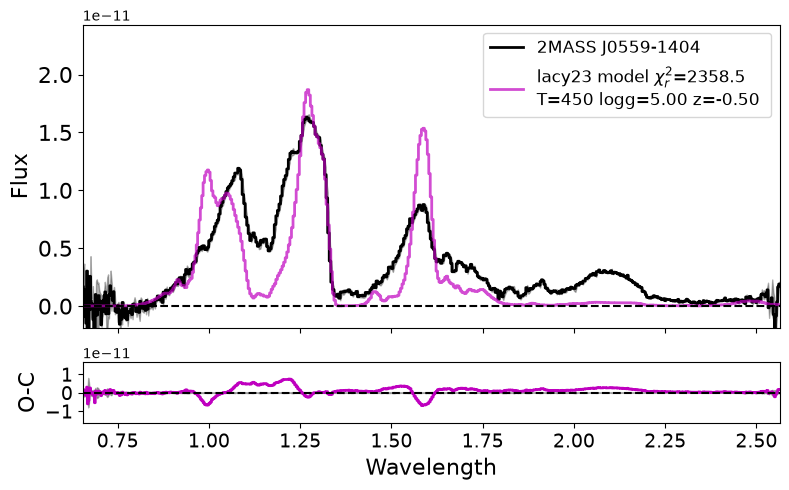

Constraining cld to within NC

Best parameters:
	model = lacy23
	cld = NC
	kzz = -0.0
	logg = 5.0
	teff = 600.0
	z = -0.5
	scale = 2.6503398163125008e-18
	chis = 1065460.4621269028
	radius = 0.7220700345075453
	dof = 562.0
	rchi = 1895.8371212222469


<Figure size 640x480 with 0 Axes>

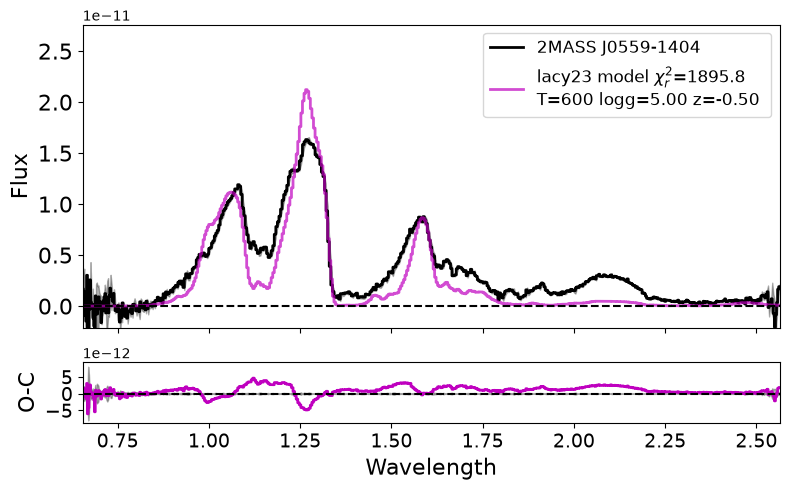

[[ 8.07188569e-03  4.98702316e+00  6.00013202e+02 -5.01687616e-01]
 [-3.51795602e-04  5.01545863e+00  6.00003997e+02 -5.01997194e-01]
 [ 1.81214836e-03  4.99327428e+00  5.99993638e+02 -4.88895556e-01]
 [-7.53258824e-03  4.99819998e+00  5.99992761e+02 -5.10398703e-01]
 [ 1.67490020e-02  4.98023463e+00  6.00001339e+02 -5.12319675e-01]
 [ 1.22229763e-02  5.02136938e+00  6.00005581e+02 -5.07037856e-01]
 [ 2.43852566e-02  4.98902398e+00  6.00014493e+02 -4.99036717e-01]
 [ 1.98184187e-03  4.98818386e+00  5.99996433e+02 -4.90396024e-01]
 [ 9.25305674e-03  5.00628166e+00  6.00012802e+02 -5.22829083e-01]
 [ 9.10642179e-03  5.01320615e+00  5.99991571e+02 -5.10184060e-01]
 [-1.49428177e-02  4.99047929e+00  5.99988031e+02 -5.06593741e-01]
 [-8.77793980e-05  5.01687910e+00  5.99999784e+02 -4.90822476e-01]
 [-1.53495025e-02  5.00219691e+00  5.99996626e+02 -5.18497689e-01]
 [-6.37230872e-03  5.00578446e+00  5.99988457e+02 -4.92375974e-01]
 [-2.48196350e-03  5.01170554e+00  5.99988150e+02 -5.06533289e

State([[ 9.77816963e-05  4.99999509e+00  5.99996596e+02 -4.99994940e-01]
 [ 5.73255266e-06  4.99999192e+00  5.99996905e+02 -4.99996752e-01]
 [ 7.53596883e-05  4.99999724e+00  5.99994124e+02 -4.99983938e-01]
 [ 1.05771023e-03  4.99999510e+00  5.99994295e+02 -4.99998287e-01]
 [ 2.62867543e-04  4.99999966e+00  5.99999483e+02 -4.99998880e-01]
 [ 1.15801268e-04  4.99999782e+00  5.99997238e+02 -4.99990007e-01]
 [ 4.04958101e-04  4.99999963e+00  5.99998400e+02 -4.99999067e-01]
 [ 2.84689118e-04  4.99999561e+00  5.99999869e+02 -4.99987133e-01]
 [ 3.13163767e-05  4.99999997e+00  5.99995778e+02 -4.99982955e-01]
 [ 6.10715346e-04  4.99999882e+00  5.99999541e+02 -4.99998956e-01]
 [ 1.19017432e-04  4.99999627e+00  5.99998965e+02 -4.99988682e-01]
 [ 2.67457824e-05  4.99999245e+00  5.99994882e+02 -4.99961125e-01]
 [ 2.16123396e-05  4.99999875e+00  5.99990823e+02 -4.99977208e-01]
 [ 6.92785126e-05  4.99999877e+00  5.99995621e+02 -4.99999871e-01]
 [ 2.29578729e-04  4.99999670e+00  5.99995472e+02 -4.999

In [ ]:
pfitc = None
pfitd = None
plimits = None
interp_dict = None
interp_cols_dict = None
interp_mask_dict = None

# Model with NO discrete columns
# =================================
# models, wave = ucdmcmc.getModelSet("dback24")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sphinx23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sonora21")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("newera25")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("lowz")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 1 discrete column (3 discrete values)
# =================================
models, wave = ucdmcmc.getModelSet("lacy23") #key error (0)
sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("exorem21") # key error in fitmcmc (0)
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 2 discrete columns (2 discrete values each)
# =================================
# models, wave = ucdmcmc.getModelSet("atmo20") # Works 
# sp = ucdmcmc.getSample("SPEX-PRISM")


# FINAL BOSS OF TESTS:
# models, wave = ucdmcmc.getModelSet("sphinx25") # key error in fitmcmc
# sp = ucdmcmc.getSample("SPEX-PRISM")

pfitc, pfitd, plimits = fitMCMC(sp, models)

interp_dict, interp_cols_dict, interp_mask_dict = get_emcee_grids_cl()

bestfit_grid = {}
bestfit_grid_key = ()
bestfit_rchi = np.inf

# for key in list(interp_dict.keys()):
#     gridfit_dict = fitGrid(sp, models, plimits={key})
for combo in interp_dict.keys():
    plimit = dict(zip(list(pfitd.keys()), list(combo)))
    # print(20*"=")
    # print(plimit)
    # print(20*"=")
    try: 
        gridfit_dict = fitGrid(sp, models, plimits=plimit)
    except KeyError:
        print(f"{combo} IS A BROKEN GRID")
        continue

    if gridfit_dict["rchi"] < bestfit_rchi:
        bestfit_grid = gridfit_dict
        bestfit_grid_key = combo
        bestfit_rchi = gridfit_dict["rchi"]

# bestfit_rchi

ipar = get_ipar(bestfit_grid_key, 
                par=bestfit_grid
                )

glorp_ensemble = emcee.EnsembleSampler(N_WALKERS, len(interp_cols_dict[bestfit_grid_key]), log_L, args=(sp, bestfit_grid_key))
glorp_ensemble.run_mcmc(ipar, 10000)

In [16]:
pfitd

{'cld': 'NC'}

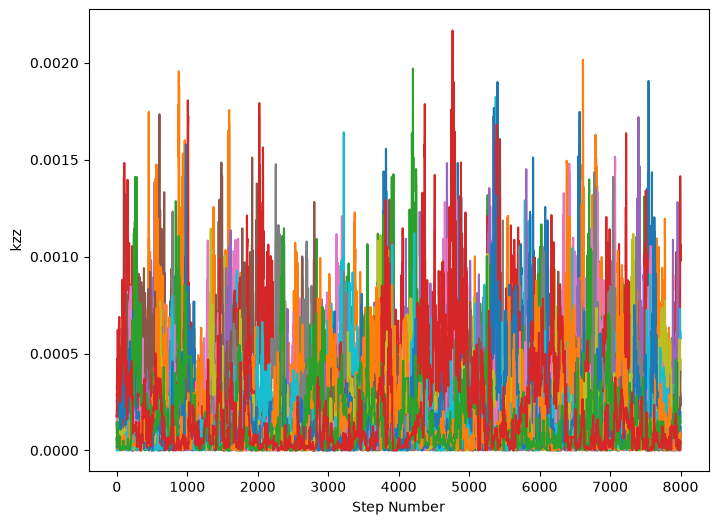

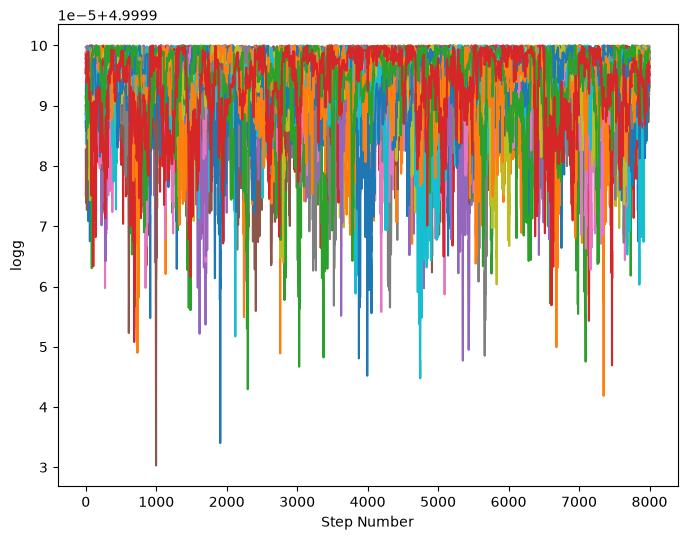

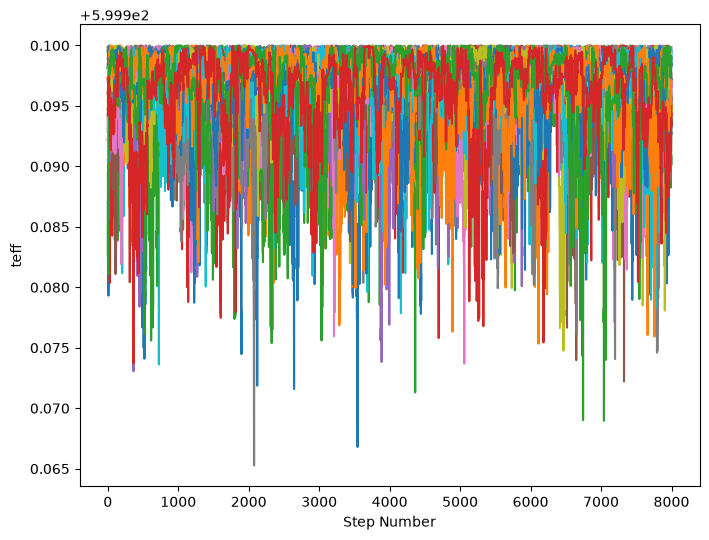

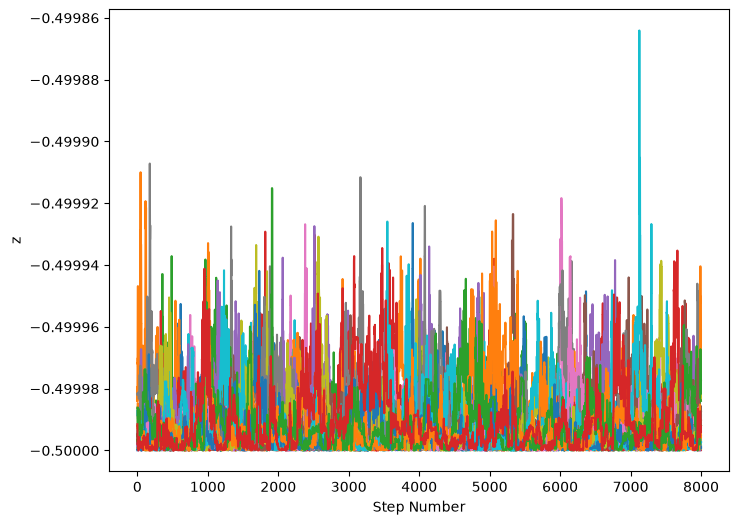

In [13]:
chain_plots(glorp_ensemble, N_BURN=2000, key=bestfit_grid_key)

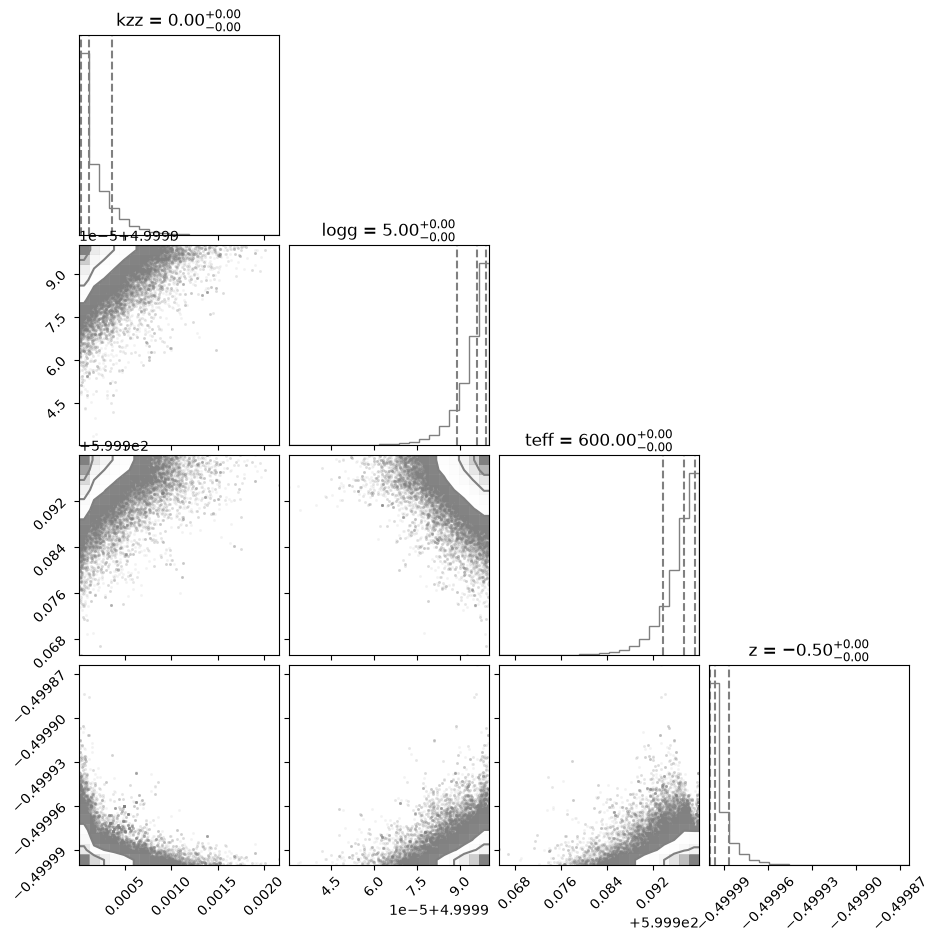

In [14]:
plot_steps(glorp_ensemble, Nburn=2000, key=bestfit_grid_key)

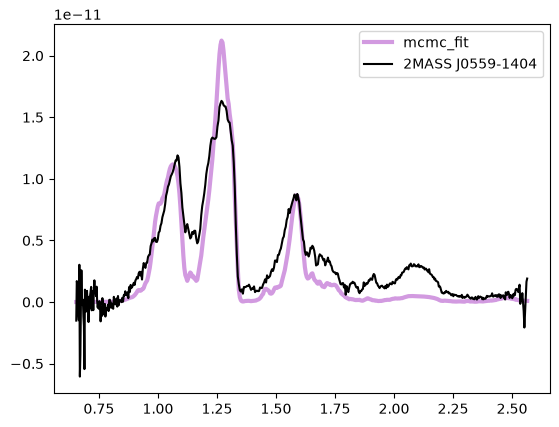

In [15]:
plot_fit(glorp_ensemble, sp, bestfit_grid_key)

# Okay havent fixed all bugs but have a pipeline in the works

Going to work on the next notebook since these are probably the last steps and to just reorganzie myself